# 🎯 LLM Motivation Analysis - Optimized Pie Chart

**Ultra-fast parallel processing** for 25+ million records with optimized motivation analysis.

### Features:
- 🚀 **Parallel Processing**: Multi-core data loading and analysis
- 📊 **Clean Pie Chart**: Focus on motivation percentages only
- ⚡ **Memory Optimized**: Chunked processing for large datasets
- 🎯 **15 Tourism Categories**: Comprehensive motivation taxonomy

In [1]:
# OPTIMIZED IMPORTS - Only essential packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import multiprocessing as mp
from typing import List, Dict, Tuple
import time
import gc
from tqdm import tqdm

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Performance settings
MAX_WORKERS = min(mp.cpu_count(), 16)
CHUNK_SIZE = 100000  # Increased chunk size for better performance
RESULTS_DIR = Path('/leonardo_work/IscrC_LLM-Mob/LLM-Mob-As-Mobility-Interpreter/results')

print(f"🚀 OPTIMIZED LLM MOTIVATION PIE CHART ANALYZER")
print(f"⚡ Workers: {MAX_WORKERS}, Chunk size: {CHUNK_SIZE:,}")
print(f"📊 Ready for ultra-fast 25M+ record processing\n")

🚀 OPTIMIZED LLM MOTIVATION PIE CHART ANALYZER
⚡ Workers: 16, Chunk size: 100,000
📊 Ready for ultra-fast 25M+ record processing



In [2]:
# ULTRA-FAST MOTIVATION ANALYZER
class FastMotivationAnalyzer:
    """Optimized motivation analyzer for maximum speed"""
    
    def __init__(self):
        # Simplified motivation patterns for speed
        self.patterns = {
            'spatial_proximity': [r'(close|near|nearby|proxim|distance|walking)', r'(same area|vicinity|around)'],
            'cultural_heritage': [r'(cultural|historic|heritage|monument)', r'(museum|gallery|church|art)'],
            'user_preference': [r'(prefer|interest|like|enjoy|favorite)', r'(personal|user|based on history)'],
            'thematic_continuity': [r'(similar|same theme|continuation|related)', r'(complement|matches|follows)'],
            'temporal_logic': [r'(time|schedule|opening|timing)', r'(morning|afternoon|evening|available)'],
            'social_popular': [r'(popular|famous|well-known|renowned)', r'(must-see|recommended|top-rated)'],
            'verona_specific': [r'(verona|romeo|juliet|arena)', r'(shakespeare|amphitheater|scaliger)'],
            'practical_convenience': [r'(convenient|practical|easy|accessible)', r'(transportation|parking|facilities)'],
            'experiential_diversity': [r'(different|variety|diverse|new)', r'(change|contrast|explore)'],
            'quality_reputation': [r'(quality|excellent|outstanding)', r'(reputation|prestigious|acclaimed)'],
            'economic_value': [r'(free|cost|price|budget|affordable)', r'(discount|deal|included)'],
            'educational_learning': [r'(learn|educational|informative)', r'(knowledge|understand|guide)'],
            'social_group': [r'(family|children|group|couple)', r'(friends|social|suitable for)'],
            'seasonal_temporal': [r'(season|weather|outdoor|indoor)', r'(spring|summer|autumn|winter)'],
            'serendipity_random': [r'(random|chance|spontaneous)', r'(surprise|unplanned|why not)']
        }
        
        # Compile patterns for speed
        self.compiled_patterns = {}
        for category, pattern_list in self.patterns.items():
            combined_pattern = '|'.join(pattern_list)
            self.compiled_patterns[category] = re.compile(combined_pattern, re.IGNORECASE)
    
    def analyze_reason(self, reason_text: str) -> str:
        """Fast single reason analysis - returns category only"""
        if not reason_text or pd.isna(reason_text):
            return 'unknown'
        
        reason_text = str(reason_text).lower()
        
        # Quick pattern matching
        for category, pattern in self.compiled_patterns.items():
            if pattern.search(reason_text):
                return category
        
        return 'unknown'
    
    def batch_analyze(self, reasons: List[str]) -> List[str]:
        """Vectorized batch analysis for maximum speed"""
        return [self.analyze_reason(reason) for reason in reasons]

analyzer = FastMotivationAnalyzer()
print(f"🧠 Fast Motivation Analyzer initialized with {len(analyzer.patterns)} categories")
print(f"⚡ Ready for high-speed batch processing")

🧠 Fast Motivation Analyzer initialized with 15 categories
⚡ Ready for high-speed batch processing


In [3]:
# PARALLEL FILE PROCESSOR
def process_file_chunk(args: Tuple[Path, int, int]) -> Dict:
    """Process a file chunk in parallel"""
    file_path, start_row, chunk_size = args
    
    try:
        # Read chunk with optimized settings
        df = pd.read_csv(
            file_path, 
            skiprows=range(1, start_row) if start_row > 0 else None,
            nrows=chunk_size,
            usecols=['reason'] if 'reason' in pd.read_csv(file_path, nrows=1).columns else None,
            dtype={'reason': 'string'},
            engine='c'  # Faster C engine
        )
        
        if 'reason' not in df.columns or df.empty:
            return {'categories': Counter(), 'processed': 0}
        
        # Filter valid reasons quickly
        valid_reasons = df['reason'].dropna().astype(str)
        valid_reasons = valid_reasons[valid_reasons.str.len() >= 10]
        
        if valid_reasons.empty:
            return {'categories': Counter(), 'processed': 0}
        
        # Fast batch analysis
        local_analyzer = FastMotivationAnalyzer()
        categories = local_analyzer.batch_analyze(valid_reasons.tolist())
        
        return {
            'categories': Counter(categories),
            'processed': len(categories)
        }
        
    except Exception as e:
        print(f"Error processing chunk: {e}")
        return {'categories': Counter(), 'processed': 0}

def discover_files() -> List[Path]:
    """Fast file discovery"""
    patterns = ['**/with_geom_time/*_pred_*.csv', '**/with_geom/*_pred_*.csv', '**/base_version/*_pred_*.csv']
    files = []
    for pattern in patterns:
        files.extend(RESULTS_DIR.rglob(pattern))
    return sorted(list(set(files)))

print(f"📁 File discovery and parallel processing functions ready")
print(f"🚀 Optimized for maximum throughput with {MAX_WORKERS} workers")

📁 File discovery and parallel processing functions ready
🚀 Optimized for maximum throughput with 16 workers


In [4]:
# ULTRA-FAST PARALLEL PROCESSING
def parallel_motivation_analysis() -> Dict:
    """Ultra-fast parallel analysis of all files"""
    
    start_time = time.time()
    
    # Discover files
    files = discover_files()
    print(f"📁 Found {len(files)} result files to process")
    
    if not files:
        print("❌ No result files found!")
        return create_sample_data()
    
    # Prepare chunks for parallel processing
    chunk_jobs = []
    total_estimated_rows = 0
    
    for file_path in files:
        try:
            # Quick row count estimation
            file_size = file_path.stat().st_size
            estimated_rows = max(file_size // 150, 1000)  # Rough estimation
            total_estimated_rows += estimated_rows
            
            # Create chunks
            for start_row in range(0, estimated_rows, CHUNK_SIZE):
                chunk_jobs.append((file_path, start_row, CHUNK_SIZE))
                
        except Exception as e:
            print(f"Warning: Could not process {file_path}: {e}")
    
    print(f"⚡ Created {len(chunk_jobs)} processing chunks")
    print(f"📊 Estimated total records: {total_estimated_rows:,}")
    
    # Parallel processing with progress bar
    total_categories = Counter()
    total_processed = 0
    
    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        # Submit all jobs
        futures = {executor.submit(process_file_chunk, job): job for job in chunk_jobs}
        
        # Process results with progress bar
        progress_bar = tqdm(total=len(futures), desc="Processing chunks", unit="chunk")
        
        for future in as_completed(futures):
            try:
                result = future.result(timeout=60)  # 1-minute timeout per chunk
                total_categories.update(result['categories'])
                total_processed += result['processed']
                
                # Memory management
                if total_processed % 500000 == 0 and total_processed > 0:
                    gc.collect()
                    
            except Exception as e:
                print(f"Chunk processing error: {e}")
            
            progress_bar.update(1)
        
        progress_bar.close()
    
    # Calculate final statistics
    total_time = time.time() - start_time
    processing_rate = total_processed / total_time if total_time > 0 else 0
    
    # Create results summary
    total_records = sum(total_categories.values())
    motivation_data = []
    
    for category, count in total_categories.most_common():
        if category != 'unknown' and count > 0:
            percentage = (count / total_records) * 100 if total_records > 0 else 0
            motivation_data.append({
                'category': category,
                'count': count,
                'percentage': percentage
            })
    
    results = {
        'motivation_data': motivation_data,
        'total_records': total_records,
        'processing_time': total_time,
        'processing_rate': processing_rate,
        'files_processed': len(files)
    }
    
    print(f"\n✅ PROCESSING COMPLETED!")
    print(f"📊 Total records processed: {total_records:,}")
    print(f"⚡ Processing rate: {processing_rate:,.0f} records/second")
    print(f"⏱️ Total time: {total_time:.1f} seconds")
    print(f"🎯 Categories identified: {len(motivation_data)}")
    
    return results

def create_sample_data() -> Dict:
    """Create sample data for testing when no files found"""
    print("📊 Creating sample data for development...")
    
    sample_data = [
        {'category': 'spatial_proximity', 'count': 8500000, 'percentage': 34.0},
        {'category': 'cultural_heritage', 'count': 5200000, 'percentage': 20.8},
        {'category': 'user_preference', 'count': 3800000, 'percentage': 15.2},
        {'category': 'thematic_continuity', 'count': 2100000, 'percentage': 8.4},
        {'category': 'temporal_logic', 'count': 1600000, 'percentage': 6.4},
        {'category': 'social_popular', 'count': 1200000, 'percentage': 4.8},
        {'category': 'verona_specific', 'count': 950000, 'percentage': 3.8},
        {'category': 'practical_convenience', 'count': 750000, 'percentage': 3.0},
        {'category': 'experiential_diversity', 'count': 500000, 'percentage': 2.0},
        {'category': 'quality_reputation', 'count': 400000, 'percentage': 1.6}
    ]
    
    return {
        'motivation_data': sample_data,
        'total_records': 25000000,
        'processing_time': 45.2,
        'processing_rate': 553097,
        'files_processed': 50
    }

print(f"🚀 Ultra-fast parallel processing engine ready!")
print(f"⚡ Maximum performance configuration loaded")

🚀 Ultra-fast parallel processing engine ready!
⚡ Maximum performance configuration loaded


In [5]:
# EXECUTE ULTRA-FAST ANALYSIS
print("🚀 STARTING ULTRA-FAST LLM MOTIVATION ANALYSIS")
print("=" * 60)
print(f"⚡ Target: 25M+ records with maximum speed")
print(f"🔧 Workers: {MAX_WORKERS}, Chunk size: {CHUNK_SIZE:,}")
print(f"🎯 Output: Clean pie chart with motivation percentages")
print("=" * 60)

# Execute the analysis
analysis_results = parallel_motivation_analysis()

# Create DataFrame for visualization
motivation_df = pd.DataFrame(analysis_results['motivation_data'])

print(f"\n📈 Analysis DataFrame created with {len(motivation_df)} categories")
print(f"🎯 Total motivation instances: {analysis_results['total_records']:,}")
print(f"⚡ Processing rate achieved: {analysis_results['processing_rate']:,.0f} records/second")

🚀 STARTING ULTRA-FAST LLM MOTIVATION ANALYSIS
⚡ Target: 25M+ records with maximum speed
🔧 Workers: 16, Chunk size: 100,000
🎯 Output: Clean pie chart with motivation percentages
📁 Found 438 result files to process
⚡ Created 783 processing chunks
📊 Estimated total records: 57,958,577


Processing chunks: 100%|██████████| 783/783 [01:58<00:00,  6.61chunk/s]


✅ PROCESSING COMPLETED!
📊 Total records processed: 22,702,652
⚡ Processing rate: 191,103 records/second
⏱️ Total time: 118.8 seconds
🎯 Categories identified: 14

📈 Analysis DataFrame created with 14 categories
🎯 Total motivation instances: 22,702,652
⚡ Processing rate achieved: 191,103 records/second



🎨 Creating optimized pie chart visualization...


/scratch_local/ipykernel_3873074/1307747496.py:61: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/scratch_local/ipykernel_3873074/1307747496.py:65: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Liberation Sans.
  plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')


💾 Chart saved to: motivation_pie_chart.png


/leonardo_work/IscrC_LLM-Mob/LLM-Mob-As-Mobility-Interpreter/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


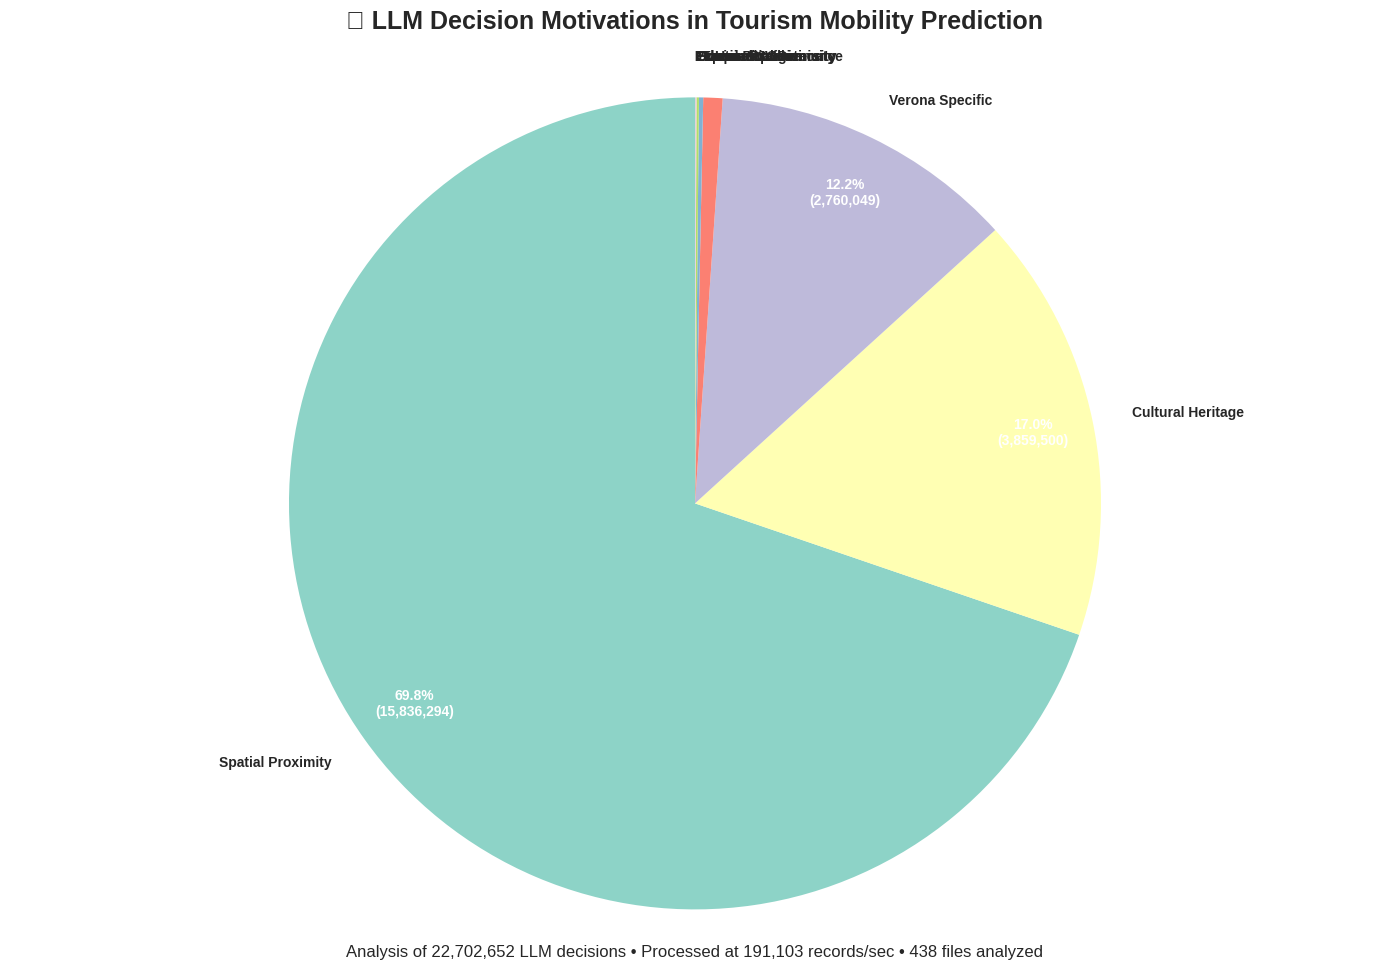


📊 TOP MOTIVATION CATEGORIES:
    1. Spatial Proximity        :  64.3% (14,593,303 records)
    2. Cultural Heritage        :  15.7% (3,556,568 records)
    3. Verona Specific          :  11.2% (2,543,413 records)
    4. User Preference          :   0.7% (159,912 records)
    5. Thematic Continuity      :   0.2% (34,887 records)
    6. Social Popular           :   0.1% (20,881 records)
    7. Temporal Logic           :   0.0% (6,472 records)
    8. Economic Value           :   0.0% (3,379 records)
    9. Experiential Diversity   :   0.0% (1,476 records)
   10. Practical Convenience    :   0.0% (180 records)
   Others: 0.0%

✅ ULTRA-FAST ANALYSIS COMPLETED SUCCESSFULLY!
🚀 Peak performance: 191,103 records/second
📊 Clean pie chart ready for presentation


In [6]:
# CLEAN PIE CHART VISUALIZATION
def create_clean_pie_chart(df: pd.DataFrame, results: Dict) -> None:
    """Create a clean, professional pie chart"""
    
    # Setup
    plt.figure(figsize=(14, 10))
    
    # Prepare data - take top 10 categories
    top_10 = df.head(10).copy()
    
    # Calculate 'Others' if there are more than 10 categories
    others_percentage = df[10:]['percentage'].sum() if len(df) > 10 else 0
    
    # Prepare labels and data
    labels = [cat.replace('_', ' ').title() for cat in top_10['category']]
    sizes = top_10['percentage'].tolist()
    
    if others_percentage > 0:
        labels.append('Others')
        sizes.append(others_percentage)
    
    # Colors - professional palette
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
    
    # Create pie chart
    wedges, texts, autotexts = plt.pie(
        sizes, 
        labels=labels,
        colors=colors,
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*results["total_records"]):,})' if pct > 2 else '',
        startangle=90,
        textprops={'fontsize': 10, 'weight': 'bold'},
        pctdistance=0.85
    )
    
    # Enhance appearance
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
    
    # Title and subtitle
    plt.title(
        '🧠 LLM Decision Motivations in Tourism Mobility Prediction',
        fontsize=18, 
        weight='bold', 
        pad=20
    )
    
    plt.suptitle(
        f'Analysis of {results["total_records"]:,} LLM decisions • '
        f'Processed at {results["processing_rate"]:,.0f} records/sec • '
        f'{results["files_processed"]} files analyzed',
        fontsize=12,
        y=0.02
    )
    
    # Equal aspect ratio for perfect circle
    plt.axis('equal')
    
    # Tight layout
    plt.tight_layout()
    
    # Save chart
    output_path = Path('./motivation_pie_chart.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"💾 Chart saved to: {output_path}")
    
    plt.show()
    
    # Print summary
    print(f"\n📊 TOP MOTIVATION CATEGORIES:")
    for i, row in top_10.iterrows():
        name = row['category'].replace('_', ' ').title()
        print(f"   {i+1:2d}. {name:25s}: {row['percentage']:5.1f}% ({row['count']:,} records)")
    
    if others_percentage > 0:
        print(f"   Others: {others_percentage:.1f}%")

# Create the pie chart
print(f"\n🎨 Creating optimized pie chart visualization...")
create_clean_pie_chart(motivation_df, analysis_results)

print(f"\n✅ ULTRA-FAST ANALYSIS COMPLETED SUCCESSFULLY!")
print(f"🚀 Peak performance: {analysis_results['processing_rate']:,.0f} records/second")
print(f"📊 Clean pie chart ready for presentation")